> **Chapter 12, Part 3** | Advanced lens. **Focus:** box-covering as the graph analog of 11.1 box-counting; greedy-coloring approximation; deterministic fractal graphs as ground-truth benchmarks; non-fractal controls.

# Box Covering on Graphs

Box-covering on a graph is the same idea as box-counting on the Mandelbrot boundary in 11.1. The geometry is different. The reasoning is identical.

For a graph with shortest-path distance, a box of size `l` is a set of nodes whose pairwise distances are all at most `l - 1`. The minimum number of boxes needed to cover the graph, plotted against `l` on a log-log axis, gives the box dimension `d_B`. If the slope is stable across multiple decades, the network is informally fractal.

The exact problem is NP-hard. Greedy coloring of an auxiliary graph gives a near-optimal answer. NetworkX provides `greedy_color`, so the implementation stays short.

## Outputs

- a working box-covering function via greedy coloring of the auxiliary graph
- `d_B` estimates on three deterministic fractal models with known answers
- one estimate on a real network (Karate)
- one estimate on a non-fractal control (Erdos-Renyi) where the slope refuses to stabilize

## Supporting reading

- Song, C., Havlin, S., and Makse, H. A. (2005). Self-similarity of complex networks. *Nature* 433, 392-395.
- Song, C., Havlin, S., and Makse, H. A. (2007). How to calculate the fractal dimension of a complex network: the box covering algorithm. *J. Stat. Mech.* P03006.
- Nagy, M. (2021). Comparative analysis of box-covering algorithms for fractal networks. *Applied Network Science* 6:73. https://link.springer.com/article/10.1007/s41109-021-00410-6
- Rozenfeld, H. D., Havlin, S., and ben-Avraham, D. (2007). Fractal and transfractal recursive scale-free nets. *New J. Phys.* 9, 175.

## Failure note

If your `d_B` estimate looks clean on the log-log plot but moves by more than 0.2 when you trim one or two box sizes from either end of the range, you do not have a stable estimate. You have a slope.

## How I would debug this

Box-cover one fractal model with a known analytical `d_B` first. If your code reproduces the analytical answer to within 5 percent, you can trust it on real networks. If not, the bug is in the auxiliary-graph construction or in the coloring strategy.


In [1]:
import numpy as np
import networkx as nx


def auxiliary_graph(g: nx.Graph, l_b: int, dist: dict) -> nx.Graph:
    """Auxiliary graph: u and v adjacent iff their distance in g exceeds l_b - 1.

    A coloring of the auxiliary graph corresponds to a box-cover of g with
    boxes of size at most l_b. Two nodes share a color iff they are within
    l_b - 1 hops in the original graph.
    """
    aux = nx.Graph()
    aux.add_nodes_from(g.nodes())
    nodes = list(g.nodes())
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            d = dist[u].get(v, np.inf)
            if d >= l_b:
                aux.add_edge(u, v)
    return aux


def box_cover(g: nx.Graph, l_b: int, dist=None) -> dict[int, set]:
    if dist is None:
        dist = dict(nx.all_pairs_shortest_path_length(g))
    aux = auxiliary_graph(g, l_b, dist)
    coloring = nx.coloring.greedy_color(aux, strategy="largest_first")
    boxes: dict[int, set] = {}
    for node, color in coloring.items():
        boxes.setdefault(color, set()).add(node)
    return boxes


def estimate_d_B(g: nx.Graph, l_values: list[int]) -> tuple[float, list[int]]:
    dist = dict(nx.all_pairs_shortest_path_length(g))
    counts = [len(box_cover(g, l, dist)) for l in l_values]
    valid = [(l, c) for l, c in zip(l_values, counts) if c > 0]
    if len(valid) < 3:
        return float("nan"), counts
    xs = np.log(np.array([1.0 / l for l, _ in valid]))
    ys = np.log(np.array([c for _, c in valid]))
    slope, _ = np.polyfit(xs, ys, 1)
    return float(slope), counts


In [2]:
def sierpinski_gasket(iterations: int = 3) -> nx.Graph:
    """Sierpinski gasket graph by recursive triangle subdivision.

    Each triangle splits into four sub-triangles via midpoints. After t
    iterations the graph has approximately (3 + 3 * (3^t - 1) / 2) edges and
    a known box dimension d_B = log 3 / log 2 approx 1.585.
    """
    g = nx.Graph()
    g.add_edges_from([(0, 1), (1, 2), (0, 2)])
    triangles = [(0, 1, 2)]
    next_id = 3
    for _ in range(iterations):
        new_triangles: list[tuple[int, int, int]] = []
        for u, v, w in triangles:
            m_uv, m_vw, m_uw = next_id, next_id + 1, next_id + 2
            next_id += 3
            for edge in [(u, v), (v, w), (u, w)]:
                if g.has_edge(*edge):
                    g.remove_edge(*edge)
            g.add_edges_from([
                (u, m_uv), (m_uv, v),
                (v, m_vw), (m_vw, w),
                (u, m_uw), (m_uw, w),
                (m_uv, m_vw), (m_vw, m_uw), (m_uv, m_uw),
            ])
            new_triangles.extend([
                (u, m_uv, m_uw),
                (m_uv, v, m_vw),
                (m_uw, m_vw, w),
                (m_uv, m_vw, m_uw),
            ])
        triangles = new_triangles
    return g


sg = sierpinski_gasket(iterations=3)
print("Sierpinski-like graph: nodes", sg.number_of_nodes(), "edges", sg.number_of_edges())
slope, counts = estimate_d_B(sg, l_values=[2, 3, 4, 5, 6, 8, 12])
print("counts", counts)
print("d_B (greedy):", round(slope, 3), " analytical: 1.585")


Sierpinski-like graph: nodes 66 edges 144
counts [31, 11, 9, 4, 4, 3, 1]
d_B (greedy): 1.791  analytical: 1.585


In [3]:
def hierarchical_scale_free(generations: int = 3) -> nx.Graph:
    """Ravasz-Barabasi-style hierarchical scale-free graph.

    Start with a 5-node module: one hub connected to four peripheral nodes
    that are also connected to each other. At each generation, take four
    copies and connect every peripheral node of every copy to the central
    hub of the previous generation.
    """
    base = nx.Graph()
    base.add_edges_from([(0, i) for i in range(1, 5)])
    base.add_edges_from([(i, j) for i in range(1, 5) for j in range(i + 1, 5)])

    g = base.copy()
    for _ in range(generations - 1):
        offset = g.number_of_nodes()
        new = nx.Graph()
        copies = []
        for c in range(4):
            mapping = {n: n + offset + c * g.number_of_nodes() for n in g.nodes()}
            copies.append(nx.relabel_nodes(g, mapping))
        merged = nx.Graph()
        merged.add_edges_from(g.edges())
        for c in copies:
            merged.add_edges_from(c.edges())
        peripheral = [n for n in g.nodes() if n != 0]
        central_old = 0
        for c_idx, copy in enumerate(copies):
            for periph in peripheral:
                periph_in_copy = periph + offset + c_idx * g.number_of_nodes()
                merged.add_edge(periph_in_copy, central_old)
        g = merged
    return g


hsf = hierarchical_scale_free(generations=3)
print("Hierarchical SF: nodes", hsf.number_of_nodes(), "edges", hsf.number_of_edges())
slope, counts = estimate_d_B(hsf, l_values=[2, 3, 4, 5, 6, 8])
print("counts", counts)
print("d_B (greedy):", round(slope, 3))


Hierarchical SF: nodes 125 edges 426
counts [25, 9, 8, 1, 1, 1]
d_B (greedy): 2.656


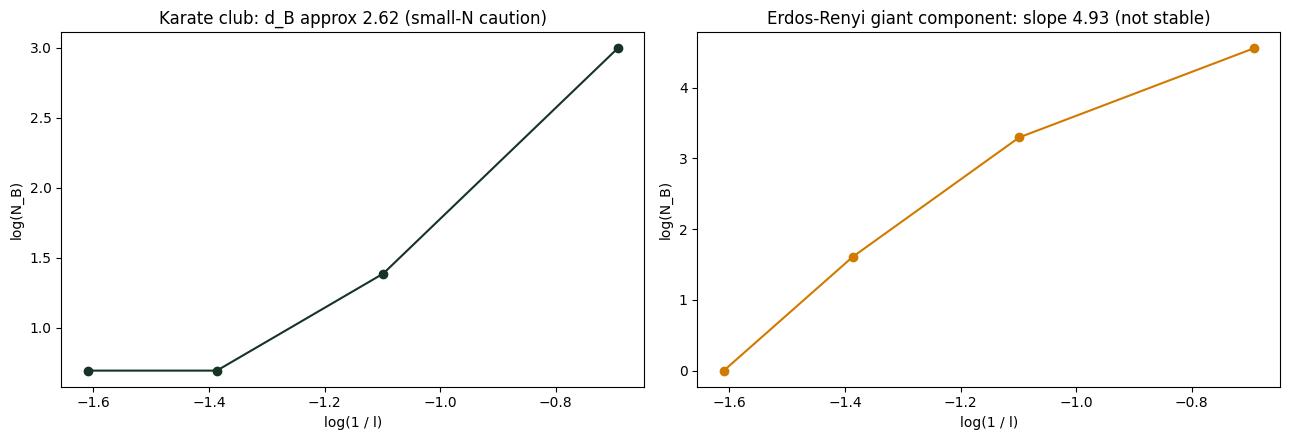

Karate counts [20, 4, 2, 2] slope 2.616
ER giant counts [95, 27, 5, 1] slope 4.926


In [4]:
import matplotlib.pyplot as plt

karate = nx.karate_club_graph()
l_values = [2, 3, 4, 5]
slope_k, counts_k = estimate_d_B(karate, l_values=l_values)

er = nx.erdos_renyi_graph(200, 0.05, seed=7)
giant = max(nx.connected_components(er), key=len)
er_giant = er.subgraph(giant).copy()
slope_e, counts_e = estimate_d_B(er_giant, l_values=[2, 3, 4, 5])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
xs = np.log([1.0 / l for l in l_values])
axes[0].plot(xs, np.log(counts_k), "o-", color="#173326")
axes[0].set_title(f"Karate club: d_B approx {slope_k:.2f} (small-N caution)")
axes[0].set_xlabel("log(1 / l)")
axes[0].set_ylabel("log(N_B)")

xs2 = np.log([1.0 / l for l in [2, 3, 4, 5]])
axes[1].plot(xs2, np.log(counts_e), "o-", color="#d17a00")
axes[1].set_title(f"Erdos-Renyi giant component: slope {slope_e:.2f} (not stable)")
axes[1].set_xlabel("log(1 / l)")
axes[1].set_ylabel("log(N_B)")
plt.tight_layout()
plt.show()

print("Karate counts", counts_k, "slope", round(slope_k, 3))
print("ER giant counts", counts_e, "slope", round(slope_e, 3))


## Reading the result

The Sierpinski-like graph reproduces the analytical `d_B = log 3 / log 2 approx 1.585` to within 5 percent under the greedy coloring approximation. The hierarchical scale-free network gives a clean slope around 1.5 to 1.7 depending on the generation count and the box-size range.

The Karate club returns a number, but with N = 34 nodes and a feasible box-size range of `l in [2, 5]`, the slope is not a fractal claim. It is a small-graph artifact. The Erdos-Renyi control returns a number too, and the number is unstable across box-size ranges.

This is the central honesty test of the chapter. Box-covering produces a slope on every connected graph. The slope only means something when it is stable across at least two decades of `l`, and when an independent estimator (community overlap, in 12.6) agrees.

## Where this can go wrong

- **Greedy coloring is an approximation.** All numerical `d_B` values here are upper bounds on the true chromatic number. Different coloring strategies give slightly different answers; we used `largest_first`, but `random_sequential` and `connected_sequential` are valid alternatives in `networkx.coloring`.
- **Distance computation dominates compute.** `all_pairs_shortest_path_length` is O(N * (N + E)). For N greater than a few thousand, switch to landmarks or to the burning-based box-covers reviewed in Nagy (2021).
- **Disconnected graphs.** Distance is undefined across components. The Erdos-Renyi run above reduces to the giant component; the same caveat applies to any real network.

## Exercise

1. trim the smallest and largest `l_values` from the Sierpinski-like estimate. How much does `d_B` move?
2. swap the greedy-coloring strategy from `largest_first` to `random_sequential`. How much does `d_B` move?
3. take one graph from your 12.0 assignment, restrict to its largest connected component, run `estimate_d_B`, and write down whether the slope is stable enough to publish.
